In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('sales_dataset.csv')

In [ ]:
print(df.head()) #top 5 rows

   Order_ID  Order_Date Customer_ID Region Product_Category  Product_Name  \
0      1001  2024-01-05        C001  South      Electronics    Smartphone   
1      1002  2024-01-06        C002  North        Furniture  Office Chair   
2      1003  2024-01-07        C003   West         Clothing       T-Shirt   
3      1004  2024-01-08        C004   East      Electronics        Laptop   
4      1005  2024-01-09        C005  South        Groceries      Rice Bag   

   Sales_Amount  Quantity  Discount  Profit Payment_Mode  Shipping_Time_Days  
0         15000         1      0.10    3000          UPI                   3  
1          7000         2      0.15    1200  Credit Card                   5  
2           800         3      0.05     200         Cash                   2  
3         55000         1      0.08    7000   Debit Card                   4  
4          1200         2      0.02     150          UPI                   1  


In [ ]:
print(df.info())#data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            15 non-null     int64  
 1   Order_Date          15 non-null     object 
 2   Customer_ID         15 non-null     object 
 3   Region              15 non-null     object 
 4   Product_Category    15 non-null     object 
 5   Product_Name        15 non-null     object 
 6   Sales_Amount        15 non-null     int64  
 7   Quantity            15 non-null     int64  
 8   Discount            15 non-null     float64
 9   Profit              15 non-null     int64  
 10  Payment_Mode        15 non-null     object 
 11  Shipping_Time_Days  15 non-null     int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 1.5+ KB
None


In [ ]:
print(df.describe()) #statistics

          Order_ID           Order_Date  Sales_Amount   Quantity   Discount  \
count    15.000000                   15     15.000000  15.000000  15.000000   
mean   1008.000000  2024-01-12 00:00:00   9866.666667   1.666667   0.092667   
min    1001.000000  2024-01-05 00:00:00    800.000000   1.000000   0.020000   
25%    1004.500000  2024-01-08 12:00:00   1750.000000   1.000000   0.060000   
50%    1008.000000  2024-01-12 00:00:00   3000.000000   2.000000   0.090000   
75%    1011.500000  2024-01-15 12:00:00  12000.000000   2.000000   0.110000   
max    1015.000000  2024-01-19 00:00:00  55000.000000   3.000000   0.200000   
std       4.472136                  NaN  14447.721850   0.723747   0.048324   

            Profit  Shipping_Time_Days  
count    15.000000           15.000000  
mean   1508.000000            3.200000  
min     120.000000            1.000000  
25%     250.000000            2.000000  
50%     500.000000            3.000000  
75%    2150.000000            4.000000  
m

In [ ]:
df.isnull().sum() #check missing values

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Region,0
Product_Category,0
Product_Name,0
Sales_Amount,0
Quantity,0
Discount,0
Profit,0


In [ ]:
df=df.dropna() # Remove missing values

In [ ]:
df.shape #sum total rows and columns

(15, 12)

In [ ]:
print("\nDuplicates:", df.duplicated().sum()) #Remove duplicate values


Duplicates: 0


In [ ]:
# Convert Date from object → datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [ ]:
# Drop duplicates if any
df.drop_duplicates(inplace=True)

In [ ]:
# Fill missing values if needed
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_4347/3119942158.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df.head()

,Order_ID,Order_Date,Customer_ID,Region,Product_Category,Product_Name,Sales_Amount,Quantity,Discount,Profit,Payment_Mode,Shipping_Time_Days
0,1001,2024-01-05,C001,South,Electronics,Smartphone,15000,1,0.10,3000,UPI,3
1,1002,2024-01-06,C002,North,Furniture,Office Chair,7000,2,0.15,1200,Credit Card,5
2,1003,2024-01-07,C003,West,Clothing,T-Shirt,800,3,0.05,200,Cash,2
3,1004,2024-01-08,C004,East,Electronics,Laptop,55000,1,0.08,7000,Debit Card,4
4,1005,2024-01-09,C005,South,Groceries,Rice Bag,1200,2,0.02,150,UPI,1


In [ ]:
#KPI
total_units = df['Quantity'].sum()
avg_price = df['Sales_Amount'].mean()


In [ ]:
print(f"Total Units Sold: {total_units}")
print(f"Average Price: ₹{avg_price:,.0f}")

Total Units Sold: 25
Average Price: ₹9,867


In [ ]:
# Aggregrates
sales_by_product = df.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False)

In [ ]:
sales_region= df.groupby('Region')['Quantity'].sum().sort_values(ascending=False)

In [ ]:
avrg_price_product=df.groupby('Product_Name')['Sales_Amount'].mean().sort_values(ascending=False)

In [ ]:

#display top results
display(sales_by_product.head(5))

,Quantity
Product_Name,
T-Shirt,3
Sugar,3
Headphones,2
Rice Bag,2
Shoes,2


In [ ]:
display(sales_region.head(5))

,Quantity
Region,
West,8
North,7
South,6
East,4


In [ ]:
display(avrg_price_product.head(5))

,Sales_Amount
Product_Name,
Laptop,55000.0
Sofa,25000.0
Tablet,18000.0
Smartphone,15000.0
Table,9000.0


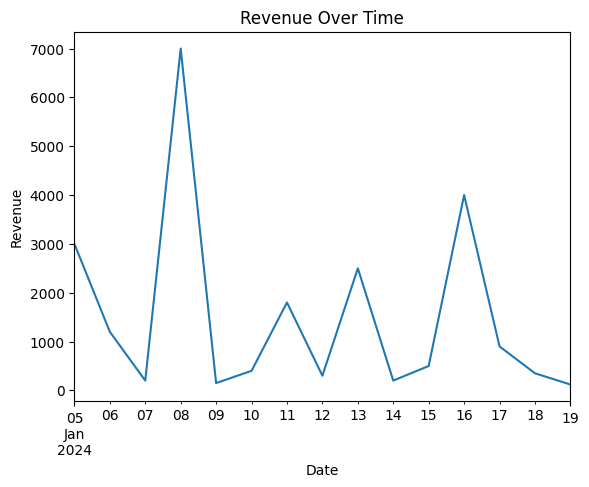

In [ ]:
# 1. Line Plot (Revenue Over Time)
# -------------------------------
plt.figure()
df.groupby('Order_Date')['Profit'].sum().plot()
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()


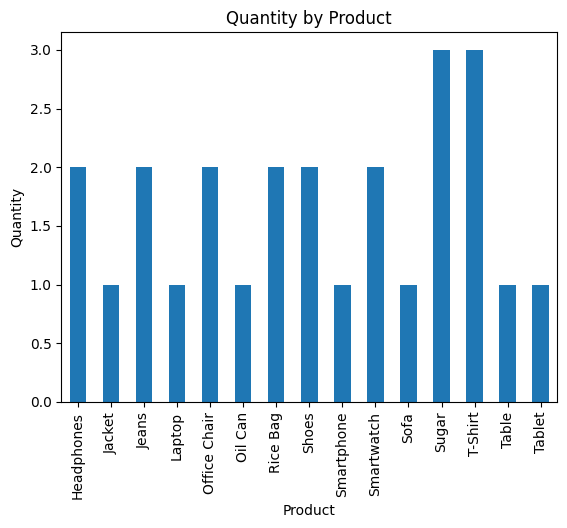

In [ ]:
# 2. Bar Plot (Quantity by Product)
# -------------------------------
plt.figure()
df.groupby('Product_Name')['Quantity'].sum().plot(kind='bar')
plt.title("Quantity by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()

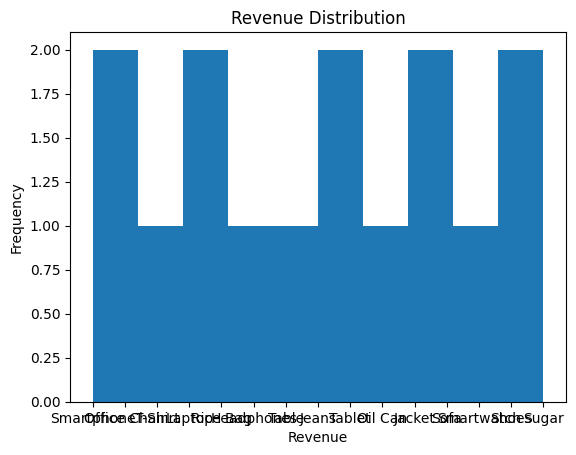

In [ ]:
# 3. revenue distribution
plt.figure()
plt.hist(df['Product_Name'])
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

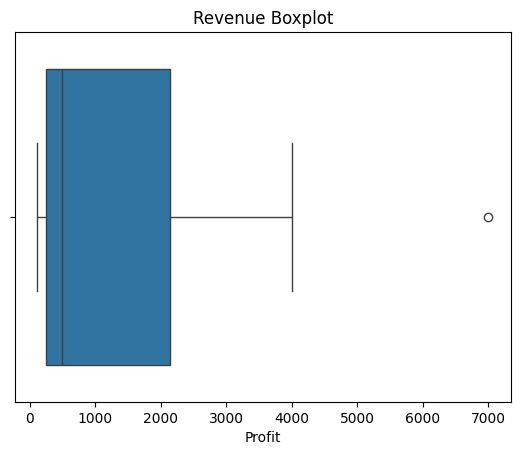

In [ ]:
# 4. Box Plot (Outliers Detection)
# -------------------------------
plt.figure()
sns.boxplot(x=df['Profit'])
plt.title("Revenue Boxplot")
plt.show()

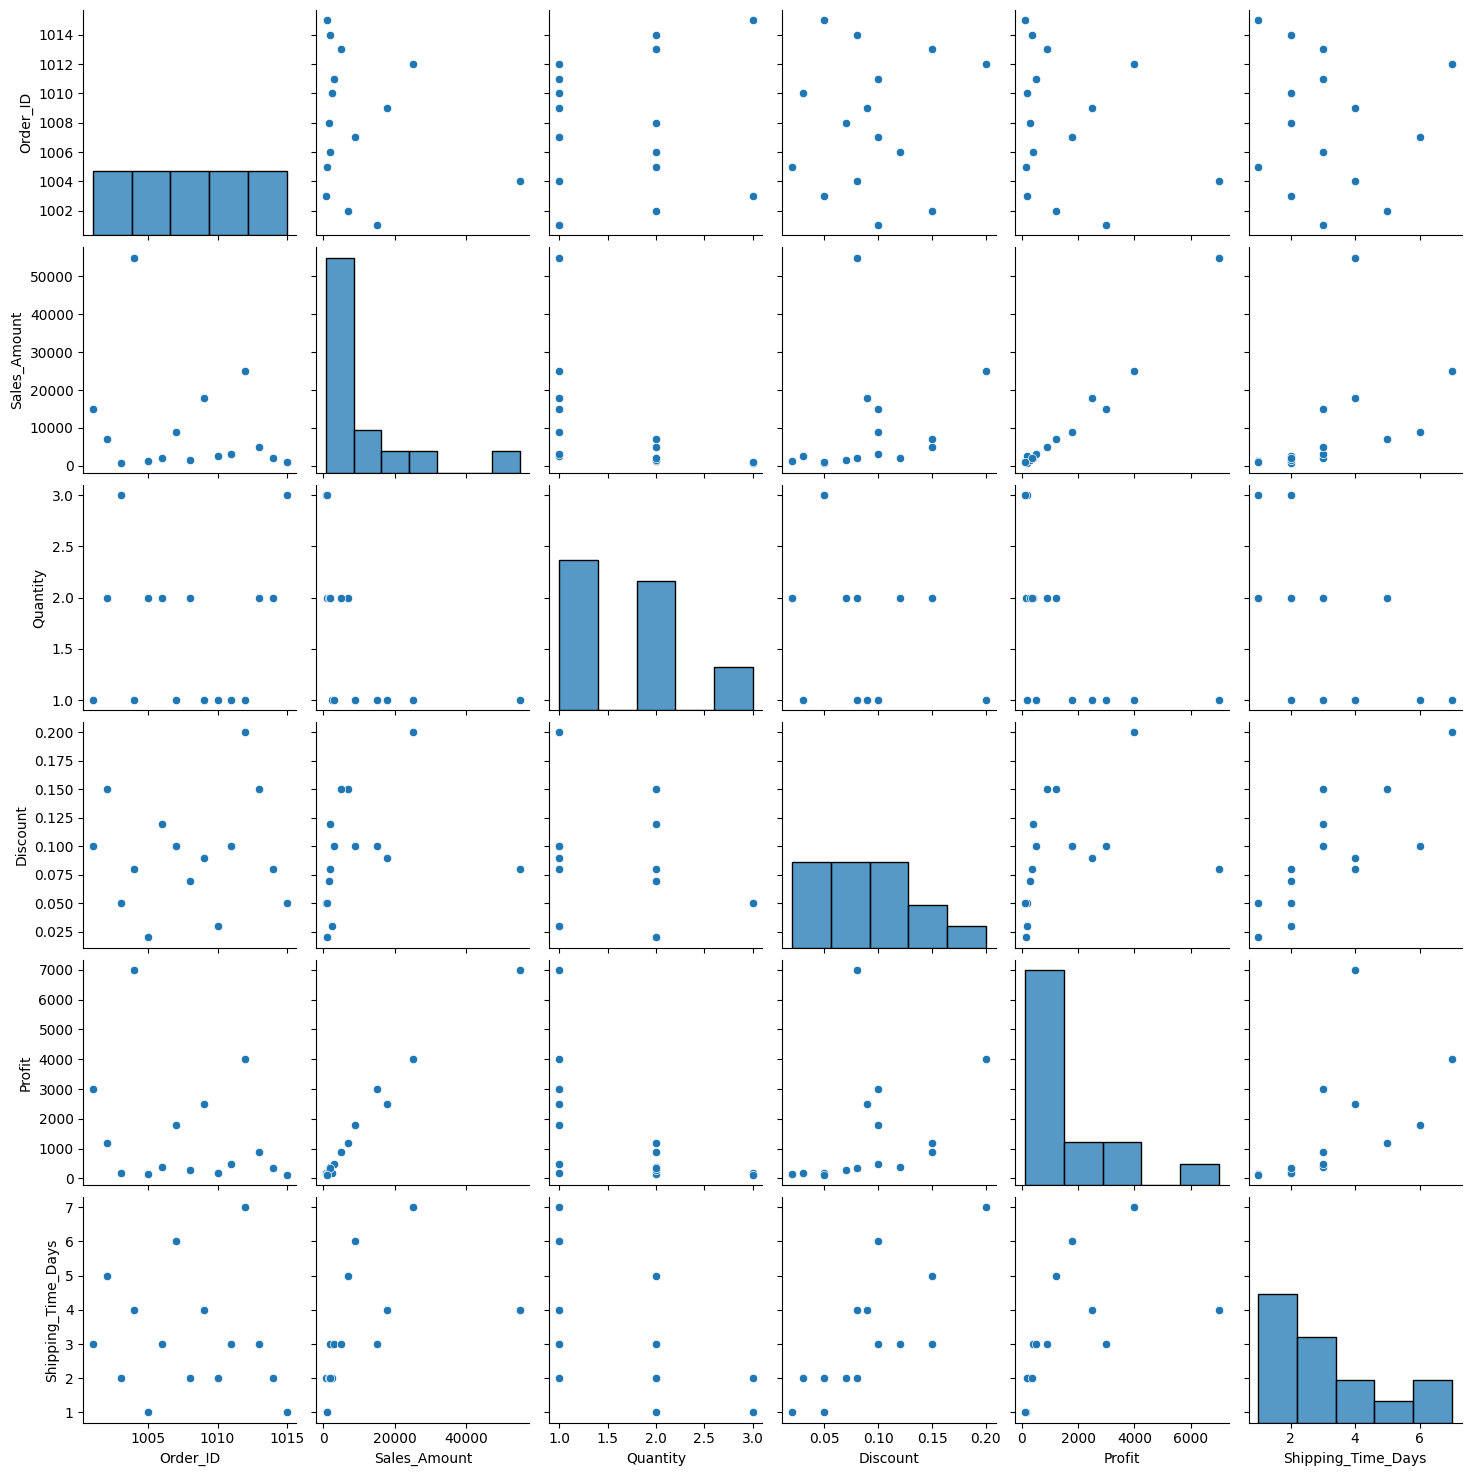

In [ ]:
# 5. Pair Plot (Seaborn)
# -------------------------------
sns.pairplot(df.select_dtypes(include='number'))
plt.show()